In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build a Market Expansion Analytics Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.7 MB/s eta 0:00:00
All libraries imported successfully!
Let's build a Market Expansion Analytics Dashboard!


In [2]:
# Generate Market Expansion Analytics Dataset
products = ['Product 1', 'Product 2', 'Product 3', 'Product 4', 'Product 5']
regions = ['East', 'West', 'South', 'North']
channels = ['Online', 'Distributor', 'Dealer', 'Retail', 'Corporate']
months = ['JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN']

# Product Sales Data
product_data = {
    'product': products,
    'above_target': [3800, 2800, 2200, 1800, 200],
    'below_target': [1400, 1600, 800, 1200, 800],
    'target': [600, 600, 600, 1000, 400]
}
product_df = pd.DataFrame(product_data)

# Monthly Sales vs Target
monthly_data = {
    'month': months,
    'actual': [1400, 1600, 1700, 1500, 1100, 900, 1400, 1500, 1700, 1400, 2400, 1200],
    'target': [1500, 1600, 1600, 1600, 1500, 1500, 1600, 1600, 1800, 1500, 1800, 1500]
}
monthly_df = pd.DataFrame(monthly_data)
monthly_df['achievement'] = monthly_df['actual'] / monthly_df['target']

# Region Data
region_data = {
    'region': regions,
    'actual': [5762, 4117, 4939, 1648],
    'target': [5569, 3979, 4774, 1593]
}
region_df = pd.DataFrame(region_data)

# Sales Growth Data
growth_months = ['JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB']
growth_pct = [5, 28, 8, -9, -37, -1, 24, 49]
growth_df = pd.DataFrame({'month': growth_months, 'growth': growth_pct})

# Channel Data
channel_data = {
    'channel': channels,
    'pct': [10, 15, 35, 25, 20]
}
channel_df = pd.DataFrame(channel_data)

# KPI Values
kpis = {
    'sales': 17952,
    'sales_target': 20652,
    'target_achievement': 90,
    'sales_last_year': 11547,
    'gross_profit': 5869,
    'gross_profit_margin': 32
}

# Gauge Values
receivable_days = 44
inventory_days = 55
gauge_target = 31
gauge_max = 181

print("Dataset generated successfully!")
print(f"Products: {len(products)}")
print(f"Regions: {len(regions)}")
print(f"Channels: {len(channels)}")
print(f"Monthly periods: {len(months)}")
print(f"Total Sales: {kpis['sales']:,}")
print(f"Target Achievement: {kpis['target_achievement']}%")
print(f"Gross Profit Margin: {kpis['gross_profit_margin']}%")

Dataset generated successfully!
Products: 5
Regions: 4
Channels: 5
Monthly periods: 12
Total Sales: 17,952
Target Achievement: 90%
Gross Profit Margin: 32%


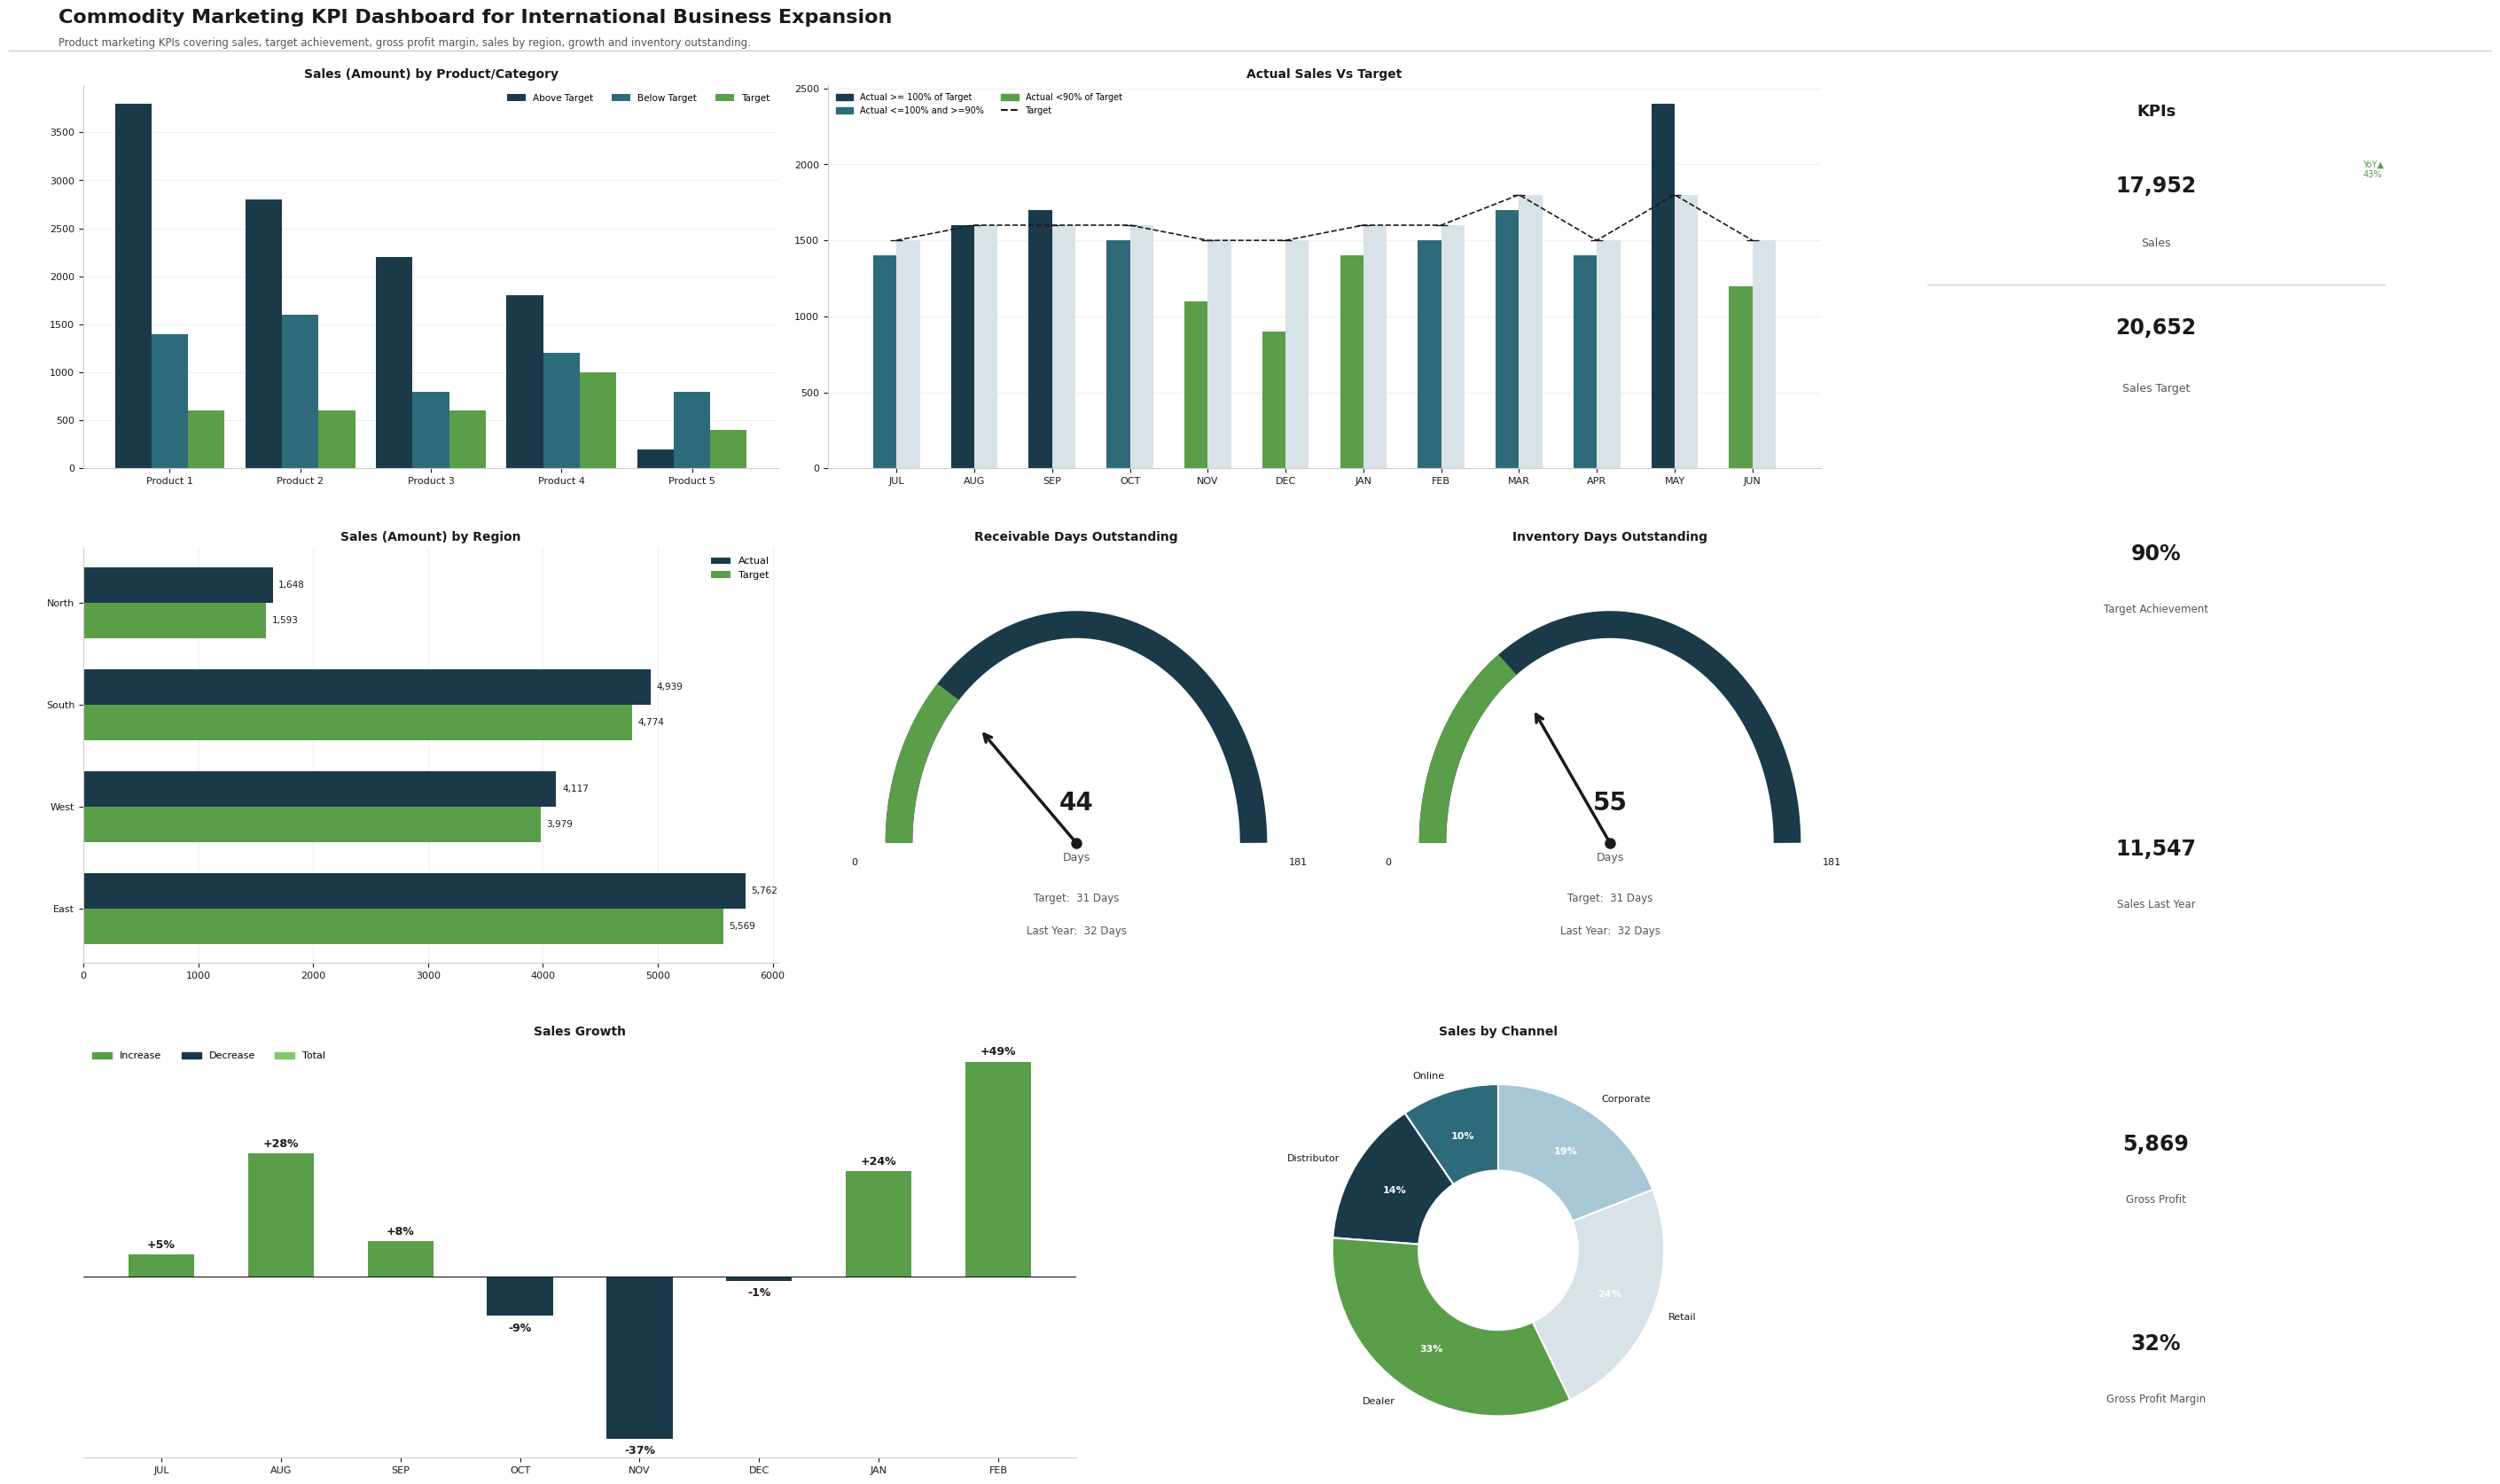

Market Expansion Dashboard


In [5]:
# Market Expansion Analytics Dashboard - FIXED
fig = plt.figure(figsize=(28, 18))
fig.patch.set_facecolor('#ffffff')

TEAL_DARK = '#1a3a4a'
TEAL_MID  = '#2e6b7a'
GREEN     = '#5a9e4a'
GREEN_LT  = '#7ec86e'
GRAY_LT   = '#d9e2e6'
WHITE     = '#ffffff'
TEXT      = '#1a1a1a'
SUBTEXT   = '#555555'
BORDER    = '#cccccc'
BG_KPI    = '#f5f8fa'

def card(ax):
    ax.set_facecolor(WHITE)
    for sp in ax.spines.values():
        sp.set_color(BORDER)
        sp.set_linewidth(0.8)

def kpi_box(ax, value, label, note=''):
    ax.set_facecolor(BG_KPI)
    for sp in ax.spines.values():
        sp.set_color(BORDER)
        sp.set_linewidth(0.8)
    ax.axis('off')
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=17, fontweight='bold', color=TEXT,
            transform=ax.transAxes)
    ax.text(0.5, 0.32, label, ha='center', va='center',
            fontsize=8.5, color=SUBTEXT, transform=ax.transAxes)
    if note:
        ax.text(0.82, 0.72, note, ha='center', fontsize=7,
                color=GREEN, transform=ax.transAxes, fontweight='bold')

def draw_gauge(ax, value, max_val, title, target, last_year):
    ax.set_facecolor(WHITE)
    for sp in ax.spines.values():
        sp.set_color(BORDER)
        sp.set_linewidth(0.8)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-0.55, 1.35)
    ax.axis('off')
    ax.set_title(title, color=TEXT, fontweight='bold',
                 fontsize=10, loc='center', pad=6)
    theta_bg = np.linspace(np.pi, 0, 300)
    ax.plot(np.cos(theta_bg), np.sin(theta_bg),
            color=TEAL_DARK, linewidth=22,
            solid_capstyle='butt', zorder=1)
    frac = min(value / max_val, 1.0)
    theta_val = np.linspace(np.pi, np.pi - frac * np.pi, 300)
    ax.plot(np.cos(theta_val), np.sin(theta_val),
            color=GREEN, linewidth=22,
            solid_capstyle='butt', zorder=2)
    angle = np.pi - frac * np.pi
    needle_len = 0.75
    ax.annotate('', xy=(needle_len*np.cos(angle), needle_len*np.sin(angle)),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=TEXT,
                                lw=2.5, mutation_scale=15))
    ax.plot(0, 0, 'o', color=TEXT, markersize=8, zorder=5)
    ax.text(-1.25, -0.10, '0', ha='center', fontsize=8, color=TEXT)
    ax.text(1.25,  -0.10, str(max_val), ha='center', fontsize=8, color=TEXT)
    ax.text(0, 0.15, f'{value}', ha='center', fontsize=20,
            fontweight='bold', color=TEXT)
    ax.text(0, -0.08, 'Days', ha='center', fontsize=9, color=SUBTEXT)
    ax.text(0, -0.27, f'Target:  {target} Days', ha='center',
            fontsize=8.5, color=SUBTEXT)
    ax.text(0, -0.42, f'Last Year:  {last_year} Days', ha='center',
            fontsize=8.5, color=SUBTEXT)

# ── TITLE ──────────────────────────────────────────
fig.text(0.02, 0.968,
         'Commodity Marketing KPI Dashboard for International Business Expansion',
         fontsize=16, fontweight='bold', color=TEXT, va='top')
fig.text(0.02, 0.950,
         'Product marketing KPIs covering sales, target achievement, gross profit margin, sales by region, growth and inventory outstanding.',
         fontsize=8.5, color=SUBTEXT, va='top')
fig.add_artist(plt.Line2D([0.0,1.0],[0.942,0.942],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── ROW 1 ───────────────────────────────────────────
# Chart 1: Sales by Product [left=0.03, bottom=0.68, width=0.28, height=0.24]
ax1 = fig.add_axes([0.03, 0.68, 0.28, 0.24])
card(ax1)
ax1.set_title('Sales (Amount) by Product/Category', color=TEXT,
              fontweight='bold', fontsize=10, loc='center', pad=6)
x = np.arange(len(product_df))
w = 0.28
ax1.bar(x - w, product_df['above_target'], w, color=TEAL_DARK,
        label='Above Target', edgecolor='none')
ax1.bar(x,     product_df['below_target'], w, color=TEAL_MID,
        label='Below Target', edgecolor='none')
ax1.bar(x + w, product_df['target'],       w, color=GREEN,
        label='Target',       edgecolor='none')
ax1.set_xticks(x)
ax1.set_xticklabels(product_df['product'], fontsize=8, color=TEXT)
ax1.tick_params(colors=TEXT, labelsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', color='#f0f0f0', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(fontsize=7.5, frameon=False, loc='upper right', ncol=3)

# Chart 2: Actual Sales vs Target [left=0.33, bottom=0.68, width=0.40, height=0.24]
ax2 = fig.add_axes([0.33, 0.68, 0.40, 0.24])
card(ax2)
ax2.set_title('Actual Sales Vs Target', color=TEXT,
              fontweight='bold', fontsize=10, loc='center', pad=6)
x2 = np.arange(len(monthly_df))
w2 = 0.30
colors_bar = []
for ach in monthly_df['achievement']:
    if ach >= 1.0:   colors_bar.append(TEAL_DARK)
    elif ach >= 0.9: colors_bar.append(TEAL_MID)
    else:            colors_bar.append(GREEN)
ax2.bar(x2 - w2/2, monthly_df['actual'], w2,
        color=colors_bar, edgecolor='none')
ax2.bar(x2 + w2/2, monthly_df['target'], w2,
        color=GRAY_LT, edgecolor='none')
ax2.plot(x2, monthly_df['target'], color=TEXT,
         linewidth=1.2, linestyle='--', marker='_', markersize=10)
ax2.set_xticks(x2)
ax2.set_xticklabels(monthly_df['month'], fontsize=8, color=TEXT)
ax2.tick_params(colors=TEXT, labelsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', color='#f0f0f0', linewidth=0.8)
ax2.set_axisbelow(True)
handles2 = [
    mpatches.Patch(color=TEAL_DARK, label='Actual >= 100% of Target'),
    mpatches.Patch(color=TEAL_MID,  label='Actual <=100% and >=90%'),
    mpatches.Patch(color=GREEN,     label='Actual <90% of Target'),
    plt.Line2D([0],[0], color=TEXT, linestyle='--', label='Target')
]
ax2.legend(handles=handles2, fontsize=7, frameon=False,
           loc='upper left', ncol=2)

# KPI Box 1: KPIs title + Sales + Sales Target
ax_k1 = fig.add_axes([0.75, 0.68, 0.23, 0.24])
ax_k1.set_facecolor(BG_KPI)
for sp in ax_k1.spines.values():
    sp.set_color(BORDER)
ax_k1.axis('off')
ax_k1.text(0.5, 0.92, 'KPIs', ha='center', fontsize=13,
           fontweight='bold', color=TEXT, transform=ax_k1.transAxes)
ax_k1.text(0.5, 0.72, '17,952', ha='center', fontsize=17,
           fontweight='bold', color=TEXT, transform=ax_k1.transAxes)
ax_k1.text(0.5, 0.58, 'Sales', ha='center', fontsize=9,
           color=SUBTEXT, transform=ax_k1.transAxes)
ax_k1.text(0.88, 0.76, 'YoY▲\n43%', ha='center', fontsize=7,
           color=GREEN, transform=ax_k1.transAxes)
ax_k1.plot([0.1,0.9],[0.48,0.48], color=BORDER,
           linewidth=0.8, transform=ax_k1.transAxes)
ax_k1.text(0.5, 0.35, '20,652', ha='center', fontsize=17,
           fontweight='bold', color=TEXT, transform=ax_k1.transAxes)
ax_k1.text(0.5, 0.20, 'Sales Target', ha='center', fontsize=9,
           color=SUBTEXT, transform=ax_k1.transAxes)

# ── ROW 2 ───────────────────────────────────────────
# Chart 3: Sales by Region
ax3 = fig.add_axes([0.03, 0.37, 0.28, 0.26])
card(ax3)
ax3.set_title('Sales (Amount) by Region', color=TEXT,
              fontweight='bold', fontsize=10, loc='center', pad=6)
y3 = np.arange(len(region_df))
h = 0.35
bars_a = ax3.barh(y3 + h/2, region_df['actual'], h,
                  color=TEAL_DARK, label='Actual', edgecolor='none')
bars_t = ax3.barh(y3 - h/2, region_df['target'], h,
                  color=GREEN, label='Target', edgecolor='none')
ax3.set_yticks(y3)
ax3.set_yticklabels(region_df['region'], fontsize=9, color=TEXT)
ax3.tick_params(colors=TEXT, labelsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='x', color='#f0f0f0', linewidth=0.8)
ax3.set_axisbelow(True)
ax3.legend(fontsize=8, frameon=False)
for bar, val in zip(bars_a, region_df['actual']):
    ax3.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=7.5, color=TEXT)
for bar, val in zip(bars_t, region_df['target']):
    ax3.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=7.5, color=TEXT)

# Chart 4: Receivable Days Gauge
ax4 = fig.add_axes([0.33, 0.37, 0.20, 0.26])
draw_gauge(ax4, receivable_days, gauge_max,
           'Receivable Days Outstanding', gauge_target, 32)

# Chart 5: Inventory Days Gauge
ax5 = fig.add_axes([0.545, 0.37, 0.20, 0.26])
draw_gauge(ax5, inventory_days, gauge_max,
           'Inventory Days Outstanding', gauge_target, 32)

# KPI Box 2: Target Achievement
ax_k2 = fig.add_axes([0.75, 0.555, 0.23, 0.115])
kpi_box(ax_k2, f"{kpis['target_achievement']}%", 'Target Achievement')

# KPI Box 3: Sales Last Year
ax_k3 = fig.add_axes([0.75, 0.37, 0.23, 0.115])
kpi_box(ax_k3, f"{kpis['sales_last_year']:,}", 'Sales Last Year')

# ── ROW 3 ───────────────────────────────────────────
# Chart 6: Sales Growth
ax6 = fig.add_axes([0.03, 0.06, 0.40, 0.26])
card(ax6)
ax6.set_title('Sales Growth', color=TEXT,
              fontweight='bold', fontsize=10, loc='center', pad=6)
colors6 = [GREEN if g > 0 else TEAL_DARK for g in growth_df['growth']]
bars6 = ax6.bar(range(len(growth_df)), growth_df['growth'],
                color=colors6, edgecolor='none', width=0.55)
ax6.axhline(0, color=TEXT, linewidth=0.8)
ax6.set_xticks(range(len(growth_df)))
ax6.set_xticklabels(growth_df['month'], fontsize=9, color=TEXT)
ax6.tick_params(colors=TEXT, labelsize=8)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax6.yaxis.set_visible(False)
ax6.grid(axis='y', color='#f0f0f0', linewidth=0.8)
ax6.set_axisbelow(True)
for bar, val in zip(bars6, growth_df['growth']):
    ypos = bar.get_height()+1.5 if val >= 0 else bar.get_height()-3.5
    ax6.text(bar.get_x()+bar.get_width()/2, ypos,
             f'{val:+d}%', ha='center', fontsize=9,
             color=TEXT, fontweight='bold')
handles6 = [
    mpatches.Patch(color=GREEN,     label='Increase'),
    mpatches.Patch(color=TEAL_DARK, label='Decrease'),
    mpatches.Patch(color=GREEN_LT,  label='Total'),
]
ax6.legend(handles=handles6, fontsize=8, frameon=False,
           loc='upper left', ncol=3)

# Chart 7: Sales by Channel
ax7 = fig.add_axes([0.46, 0.06, 0.28, 0.26])
card(ax7)
ax7.set_title('Sales by Channel', color=TEXT,
              fontweight='bold', fontsize=10, loc='center', pad=6)
donut_colors = [TEAL_MID, TEAL_DARK, GREEN, GRAY_LT, '#a8c8d8']
wedges, texts, autotexts = ax7.pie(
    channel_df['pct'], labels=channel_df['channel'],
    colors=donut_colors, autopct='%1.0f%%', startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=1.5))
for t in texts:
    t.set_fontsize(8)
    t.set_color(TEXT)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('white')
    at.set_fontweight('bold')

# KPI Box 4: Gross Profit
ax_k4 = fig.add_axes([0.75, 0.185, 0.23, 0.115])
kpi_box(ax_k4, f"{kpis['gross_profit']:,}", 'Gross Profit')

# KPI Box 5: Gross Profit Margin
ax_k5 = fig.add_axes([0.75, 0.06, 0.23, 0.115])
kpi_box(ax_k5, f"{kpis['gross_profit_margin']}%", 'Gross Profit Margin')

plt.savefig('market_expansion_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()
print("Market Expansion Dashboard")

In [6]:
from google.colab import files

# Save datasets
growth_df.to_csv('market_expansion_data.csv', index=False)
region_df.to_csv('region_data.csv', index=False)
monthly_df.to_csv('monthly_sales_data.csv', index=False)

# Save README
readme = """
# Market Expansion Analytics

## Overview
- **Products:** 5
- **Regions:** 4 (East, West, South, North)
- **Channels:** 5 (Online, Distributor, Dealer, Retail, Corporate)
- **Period:** July 2023 - June 2024
- **Total Sales:** 17,952
- **Sales Target:** 20,652
- **Target Achievement:** 90%
- **Gross Profit Margin:** 32%

## Dashboard Sections
1. Sales by Product/Category — Above Target, Below Target, Target
2. Actual Sales vs Target — Monthly comparison with target line
3. KPI Cards — Sales, Sales Target, Target Achievement, Sales Last Year, Gross Profit, Gross Profit Margin
4. Sales by Region — East, West, South, North actual vs target
5. Receivable Days Outstanding — Gauge chart (44 days vs 31 target)
6. Inventory Days Outstanding — Gauge chart (55 days vs 31 target)
7. Sales Growth — Monthly waterfall chart
8. Sales by Channel — Donut chart across 5 channels

## Key Insights
- Target Achievement at 90% across all regions
- East region leads with 5,762 actual vs 5,569 target
- Receivable days at 44 vs 31 day target
- Inventory days at 55 vs 31 day target
- Strong recovery in Jan/Feb with 24% and 49% growth

## Technologies
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- Google Colab (T4 GPU)
"""

with open('README_results.md', 'w') as f:
    f.write(readme)

print("Downloading all files...")
files.download('market_expansion_dashboard.png')
files.download('market_expansion_data.csv')
files.download('region_data.csv')
files.download('monthly_sales_data.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
